In [1]:
%pip install xgboost pandas scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.5 MB/s eta 0:01:07
   ---------------------------------------- 1.0/101.7 MB 1.8 MB/s eta 0:00:56
    --------------------------------------- 1.3/101.7 MB 1.8 MB/s eta 0:00:57
    --------------------------------------- 1.6/101.7 MB 1.7 MB/s eta 0:00:58
    --------------------------------------- 1.8/101.7 MB 1.6 MB/s eta 0:01:02
    --------------------------------------- 2.1/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 2.4/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 2.4/101.7 MB 1.4 MB/s eta 0:01:10
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:16
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:16
   - --


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**1. Initial Setup and Data Loading**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

df = pd.read_csv('../data/Processed/cleaned_dataset.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


**2. Data Preparation**

In [5]:
# Convert boolean columns to integers
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Encode the target as numeric labels for XGBoost
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1}).astype(int)

# Define Features (X) and Target (y)
X = df.drop('Attrition', axis=1)

# One-hot encode categorical feature columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

y = df['Attrition']

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data splitting completed.")
print(f'Encoded categorical columns: {list(cat_cols)}')

Data splitting completed.
Encoded categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


**3. Baseline XGBoost Model**

In [7]:
# Initialize and train the baseline model
base_model = xgb.XGBClassifier(
    eval_metric='logloss', 
    random_state=42
)

base_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = base_model.predict(X_test)

print("--- Baseline Model Performance ---")
print(classification_report(y_test, y_pred))

--- Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.63      0.26      0.36        47

    accuracy                           0.86       294
   macro avg       0.75      0.61      0.64       294
weighted avg       0.83      0.86      0.83       294



**4. Hyperparameter Tuning**

In [8]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [1, 3, 5] 
}

# Setup Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the search
print("Starting Hyperparameter Tuning...")
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.7, 'scale_pos_weight': 5, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}


**5. Final Model Evaluation and Feature Importance**

--- Tuned Model Performance ---
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       247
           1       0.42      0.38      0.40        47

    accuracy                           0.82       294
   macro avg       0.65      0.64      0.65       294
weighted avg       0.81      0.82      0.81       294



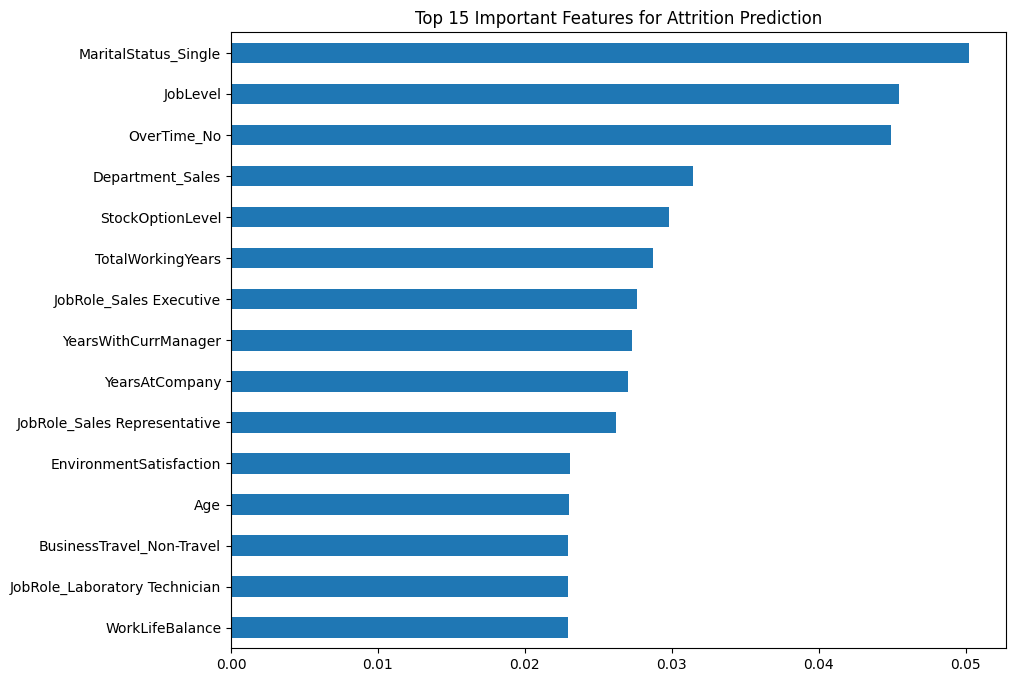

In [9]:
# Get the best model from search
best_model = random_search.best_estimator_

# Final Evaluation
y_final_pred = best_model.predict(X_test)
print("--- Tuned Model Performance ---")
print(classification_report(y_test, y_final_pred))

# Plot Feature Importance
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Important Features for Attrition Prediction')
plt.gca().invert_yaxis()
plt.show()

**6. Visualize XGBoost Decision Tree**

In [10]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Graphviz executable 'dot' is not available on PATH, so the tree diagram cannot be rendered.
Showing feature importance as a safe fallback instead.


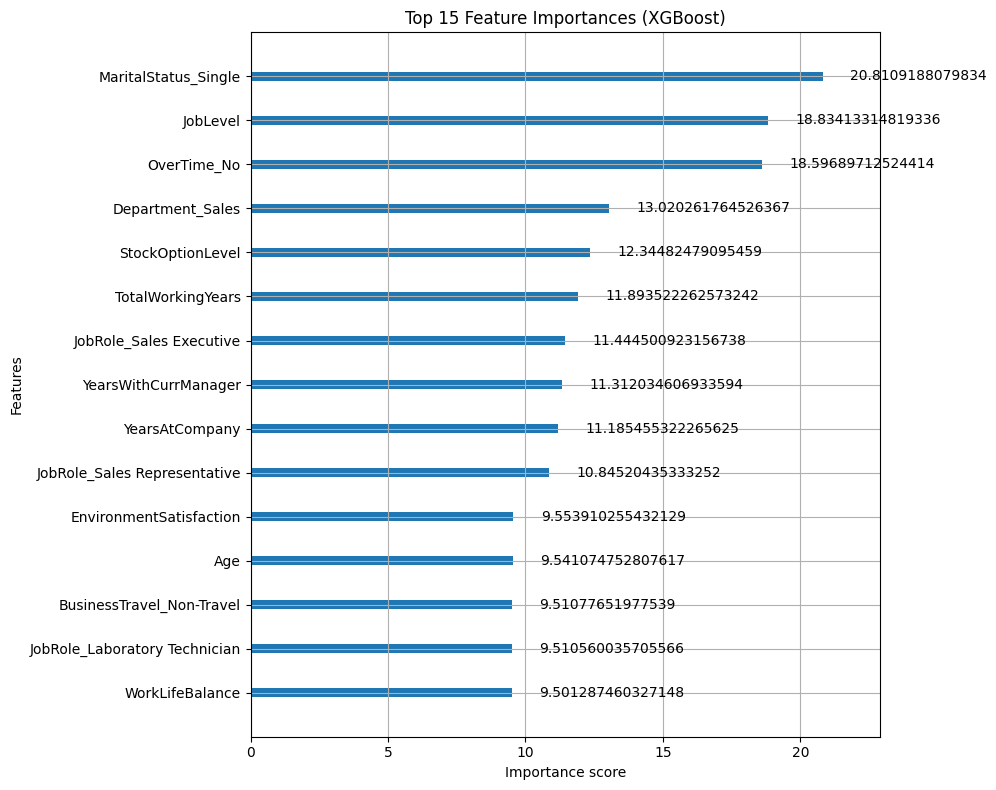


First tree dump:
0:[JobLevel<2] yes=1,no=2,missing=2
1:[OverTime_No] yes=3,no=4
		3:[JobInvolvement<4] yes=7,no=8,missing=8
			7:[NumCompaniesWorked<1] yes=15,no=16,missing=16
				15:leaf=-0.0111084096
				16:leaf=0.082281135
			8:leaf=-0.0588966385
		4:[TotalWorkingYears<3] yes=9,no=10,missing=10
			9:[Age<32] yes=17,no=18,missing=18
				17:leaf=0.0706219226
				18:leaf=-0.0248547103
10:[MaritalStatus_Single] yes=19,no=20
				19:leaf=-0.0627378002
				20:leaf=0.0193147976
	2:[NumCompaniesWorked<4] yes=5,no=6,missing=6
		5:[MonthlyRate<11563] yes=11,no=12,missing=12
			11:[MonthlyIncome<4538] yes=21,no=22,missing=22
				21:leaf=0.035048794
				22:leaf=-0.0421505719
			12:[DailyRate<726] yes=23,no=24,missing=24
				23:leaf=-0.0457579494
				24:leaf=-0.0876203626
6:[JobRole_Sales Executive] yes=13,no=14
			13:[DailyRate<989] yes=25,no=26,missing=26
				25:leaf=-0.0119743925
				26:leaf=-0.0697432011
			14:[StockOptionLevel<1] yes=27,no=28,missing=28
				27:leaf=0.0690345317
				28:leaf=

In [12]:
import shutil
import xgboost as xgb
import matplotlib.pyplot as plt

if shutil.which('dot') is None:
    print("Graphviz executable 'dot' is not available on PATH, so the tree diagram cannot be rendered.")
    print("Showing feature importance as a safe fallback instead.")

    fig, ax = plt.subplots(figsize=(10, 8))
    xgb.plot_importance(best_model, ax=ax, importance_type='gain', max_num_features=15)
    ax.set_title('Top 15 Feature Importances (XGBoost)')
    plt.tight_layout()
    plt.show()

    print('\nFirst tree dump:')
    print(best_model.get_booster().get_dump(with_stats=False)[0])
else:
    fig, ax = plt.subplots(figsize=(80, 40), dpi=100)
    xgb.plot_tree(best_model, num_trees=0, ax=ax, rankdir='LR')
    plt.savefig("xgboost_tree_high_res.png", bbox_inches='tight', dpi=300)
    plt.show()